In [1]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway, tukey_hsd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

ANOVA ANALYSIS

In [2]:
# Loading main data file
wb = pd.read_csv('../data/world-bank.csv')
wb.head()

,Country Name,Country Code,Region,IsCountry,Income group,Year,GenderEquality,PoliticalStability,GenderEducation,BirthSex,...,Fertility,LandArea,ForestArea,RuralArea,UrbanArea,Density,TaxRevenue,Mobile,FixedTelephone,GovernmentExpenditure
0,Afghanistan,AFG,South Asia,1,Low income,2022,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,South Asia,1,Low income,2021,NaN,-2.529855,NaN,1.052,...,4.643,NaN,NaN,NaN,NaN,NaN,NaN,22678024.0,145787.0,NaN
2,Afghanistan,AFG,South Asia,1,Low income,2020,1.5,-2.705030,0.38689,1.052,...,4.750,652230.0,1.852782,NaN,NaN,59.752281,NaN,22678024.0,145787.0,NaN
3,Afghanistan,AFG,South Asia,1,Low income,2019,1.5,-2.655531,NaN,1.053,...,4.870,652230.0,1.852782,NaN,NaN,57.908252,NaN,22580071.0,134636.0,NaN
4,Afghanistan,AFG,South Asia,1,Low income,2018,1.5,-2.763864,0.34523,1.053,...,5.002,652230.0,1.852782,NaN,NaN,56.248231,NaN,21976355.0,127794.0,NaN


In [3]:
# ANOVA for to study the differences how Internet vary between income groups in 2016
# Isolate all income groups (H_0 = all groups have the same mean, H_a = at least one group has a different mean)
high_income = wb[(wb['Income group'] == 'High income') & (wb['Year'] == 2016)]
u_middle_income = wb[(wb['Income group'] == 'Upper middle income') & (wb['Year'] == 2016)]
l_middle_income = wb[(wb['Income group'] == 'Lower middle income') & (wb['Year'] == 2016)]
low_income = wb[(wb['Income group'] == 'Low income') & (wb['Year'] == 2016)]

f_oneway(high_income['Internet'].dropna(),
         u_middle_income['Internet'].dropna(),
         l_middle_income['Internet'].dropna(),
         low_income['Internet'].dropna())

F_onewayResult(statistic=np.float64(267.7799918504105), pvalue=np.float64(1.6223023018405315e-68))

In [4]:
# p value < 0.05, therefore we run tukey HSD test to find out which groups are different
res = tukey_hsd(high_income['Internet'].dropna(), u_middle_income['Internet'].dropna(), l_middle_income['Internet'].dropna(), low_income['Internet'].dropna())
print(res)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)     28.942     0.000    22.690    35.194
 (0 - 2)     51.996     0.000    45.851    58.142
 (0 - 3)     71.611     0.000    64.014    79.208
 (1 - 0)    -28.942     0.000   -35.194   -22.690
 (1 - 2)     23.055     0.000    16.392    29.717
 (1 - 3)     42.669     0.000    34.648    50.690
 (2 - 0)    -51.996     0.000   -58.142   -45.851
 (2 - 1)    -23.055     0.000   -29.717   -16.392
 (2 - 3)     19.615     0.000    11.676    27.553
 (3 - 0)    -71.611     0.000   -79.208   -64.014
 (3 - 1)    -42.669     0.000   -50.690   -34.648
 (3 - 2)    -19.615     0.000   -27.553   -11.676



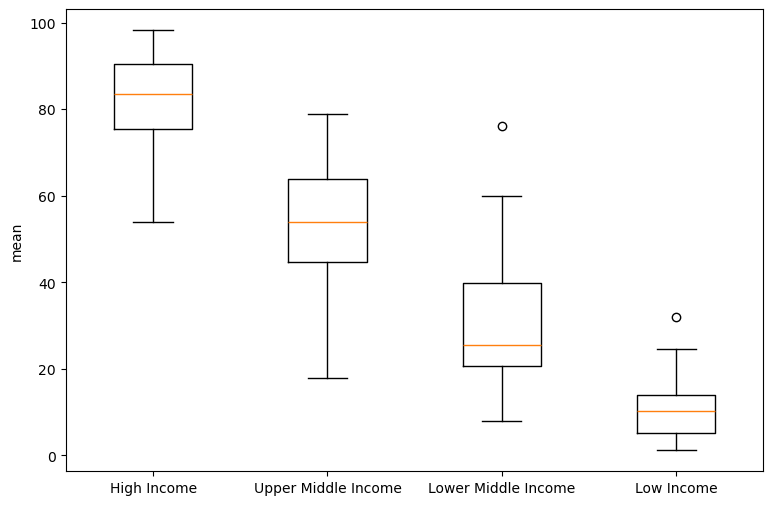

In [5]:
# plotting means to visualize the differences
fig, axs = plt.subplots(1, 1, figsize=(9, 6))
axs.boxplot([high_income['Internet'].dropna(), u_middle_income['Internet'].dropna(), l_middle_income['Internet'].dropna(), low_income['Internet'].dropna()])
axs.set_xticklabels(["High Income", "Upper Middle Income", "Lower Middle Income", "Low Income"]) 
axs.set_ylabel("mean") 
plt.show()

REGRESSION ANALYSIS

In [6]:
# Regression analysis between Internet usage and political stability for the year 2016
# Isolate the data for 2016
data_2016 = wb[wb['Year'] == 2016]
data_2016.head()

,Country Name,Country Code,Region,IsCountry,Income group,Year,GenderEquality,PoliticalStability,GenderEducation,BirthSex,...,Fertility,LandArea,ForestArea,RuralArea,UrbanArea,Density,TaxRevenue,Mobile,FixedTelephone,GovernmentExpenditure
6,Afghanistan,AFG,South Asia,1,Low income,2016,1.5,-2.671054,NaN,1.055,...,5.262,652230.0,1.852782,NaN,NaN,53.104284,9.502653,21602982.0,114192.0,NaN
16,Albania,ALB,Europe & Central Asia,1,Upper middle income,2016,NaN,0.344645,1.32128,1.088,...,1.551,27400.0,28.802190,NaN,NaN,104.967190,17.590230,3369756.0,248640.0,1.324573e+09
26,Algeria,DZA,Middle East & North Africa,1,Lower middle income,2016,NaN,-1.097526,1.40208,1.044,...,3.051,2381741.0,0.821248,NaN,NaN,16.936908,NaN,47041321.0,3404709.0,3.625092e+10
36,American Samoa,ASM,East Asia & Pacific,1,Upper middle income,2016,NaN,1.193236,NaN,1.060,...,NaN,200.0,86.250000,NaN,NaN,252.240000,NaN,NaN,NaN,NaN
46,Andorra,AND,Europe & Central Asia,1,High income,2016,NaN,1.413419,NaN,1.061,...,NaN,470.0,34.042553,NaN,NaN,154.340426,NaN,76132.0,38694.0,NaN


In [7]:
# Seperate predictors and target variable
clean_data = data_2016[['PoliticalStability', 'Internet']].dropna()

X = clean_data['PoliticalStability']
X = sm.add_constant(X)  # adding a constant for the intercept
y = clean_data['Internet']

# Build OLS regression model
est = sm.OLS(y, X)
est = est.fit()
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:               Internet   R-squared:                       0.346
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     103.5
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           8.62e-20
Time:                        21:44:32   Log-Likelihood:                -903.39
No. Observations:                 198   AIC:                             1811.
Df Residuals:                     196   BIC:                             1817.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 51.1482      1

In [8]:
# Checking results
est.params

const                 51.148248
PoliticalStability    16.989853
dtype: float64

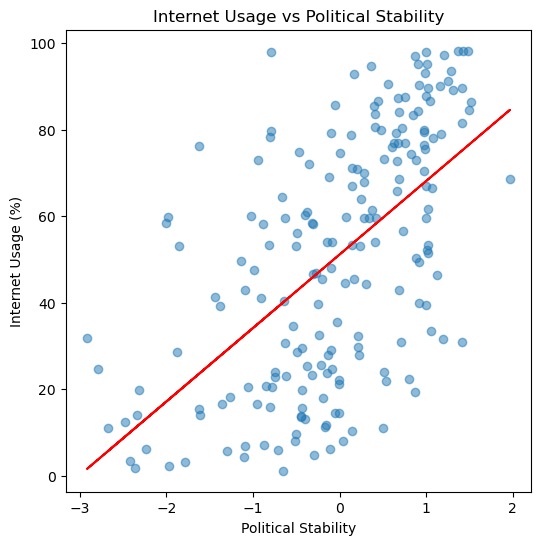

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(clean_data['PoliticalStability'], clean_data['Internet'], alpha=0.5)
ax.plot(clean_data['PoliticalStability'], est.predict(X), color='red')

ax.set_xlabel("Political Stability")
ax.set_ylabel("Internet Usage (%)")
ax.set_title("Internet Usage vs Political Stability")

plt.show()

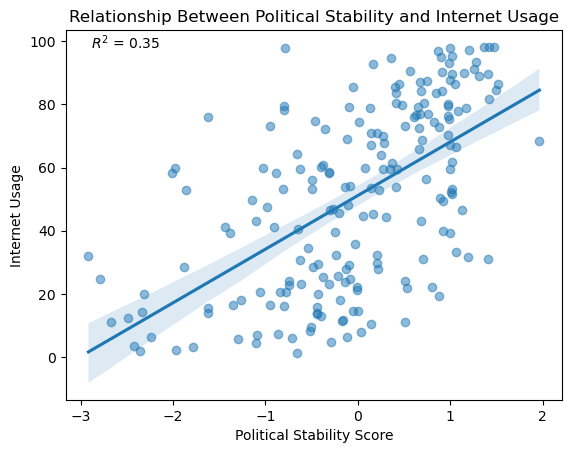

In [10]:
sns.regplot(x='PoliticalStability', y='Internet', data=clean_data, scatter_kws={'alpha':0.5})

plt.xlabel("Political Stability Score")
plt.ylabel("Internet Usage")
plt.title("Relationship Between Political Stability and Internet Usage")
plt.text(0.05, 0.95, f"$R^2$ = {est.rsquared:.2f}", transform=plt.gca().transAxes)

plt.show()

Random Forest Regressor

In [11]:
# RFR for multiple predictors (Internet ~ GDP + Political Stability + Income)
wb.columns

Index(['Country Name', 'Country Code', 'Region', 'IsCountry', 'Income group',
       'Year', 'GenderEquality', 'PoliticalStability', 'GenderEducation',
       'BirthSex', 'Income', 'PlanePassengers', 'PlaneDepartures',
       'Electricity', 'PM2.5', 'CO2Emissions', 'Unemployment', 'Poverty',
       'BattleDeaths', 'CompulsoryEducation', 'Literacy', 'Death', 'Alcohol',
       'Diabetes', 'DeathsCD', 'DeathsNCD', 'GDP', 'Internet', 'Population',
       'Rural', 'Urban', 'Suicide', 'Homicide', 'Military', 'LegalRights',
       'Birth', 'Fertility', 'LandArea', 'ForestArea', 'RuralArea',
       'UrbanArea', 'Density', 'TaxRevenue', 'Mobile', 'FixedTelephone',
       'GovernmentExpenditure'],
      dtype='object')

In [12]:
# preparing data for processing
filtered_data = wb[['Internet','GDP','PoliticalStability','Income']].dropna()

X = filtered_data[['GDP','PoliticalStability','Income']]
y = filtered_data['Internet']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# creating and fitting model
regressor = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    oob_score=True
)

regressor.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [14]:
# Evaluating model
print("Out-of-Bag Score:", regressor.oob_score_)

y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

Out-of-Bag Score: 0.6727254006907148
Mean Squared Error: 324.0845619638975
R-squared: 0.5849215887764971


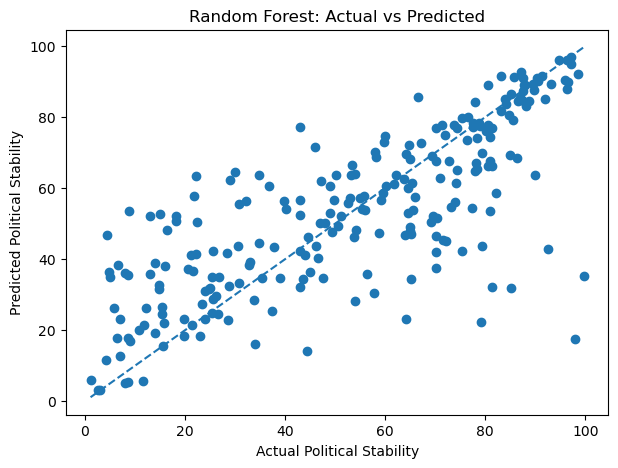

In [15]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Political Stability")
plt.ylabel("Predicted Political Stability")
plt.title("Random Forest: Actual vs Predicted")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")  

plt.show()

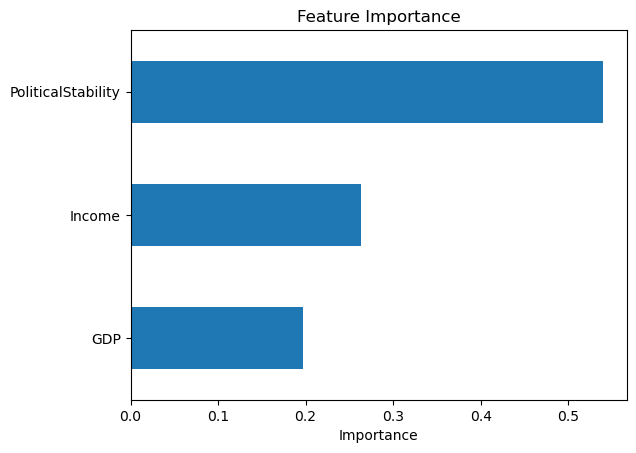

In [16]:
# Importance of predictos
importance = pd.Series(regressor.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

In [18]:
# Dumping model for future use
import joblib
joblib.dump(regressor, '../models/random_forest_model.joblib')

['../models/random_forest_model.joblib']